In [1]:
# Acesso à raiz do projeto

import sys
import os

# Caminho até a raiz do projeto
sys.path.append(os.path.abspath("../../"))


In [2]:
# Importação das bibliotecas necessárias

from modulos.gerais import preparar_iris, exibir_resultado, exibir_relatorio_de_classificacao, preparar_newsgroup
from modulos.knn import preparar_knn, treinar_k, atualizar_melhor_desempenho_k, exibir_melhor_resultado_do_knn, exibir_grafico_comparativo


In [3]:
# Carregamento da base 20newsgroup, bem como dados de treinamento e teste
X_train, X_test, y_train, y_test, feature_names, target_names = preparar_newsgroup()
target_names = ['computação_grafica', 'anuncios_diversos', 'medicina_e_saude', 'politica_em_geral']


In [4]:
# Estabelecendo as variáveis que serão usadas no loop do KNN
valores_k, resultados_acuracia, melhor_k, melhor_f1 = preparar_knn()


In [5]:
for k in valores_k:
    # Treinando e avaliando o modelo de acordo com o K atual
    y_pred_knn, acuracia_knn, precisao_knn, revocacao_knn, f1_knn = treinar_k(
        k, resultados_acuracia, X_train, y_train, X_test, y_test
    )

    # Exibindo o resultado do K atual
    exibir_resultado(
        acuracia_knn, precisao_knn, revocacao_knn, f1_knn,
        f"KNN (K = {k})"
    )

    # Atualizando qual é o melhor modelo baseado no F1-Score
    melhor_f1, melhor_k = atualizar_melhor_desempenho_k(f1_knn, k, melhor_f1, melhor_k)

exibir_melhor_resultado_do_knn(melhor_k, melhor_f1)


MÉTRICAS DE AVALIAÇÃO - KNN (K = 1)
Acurácia:  0.7636
Precisão:  0.7712
Revocação: 0.7645
F1-Score:  0.7656
MÉTRICAS DE AVALIAÇÃO - KNN (K = 3)
Acurácia:  0.7589
Precisão:  0.7792
Revocação: 0.7589
F1-Score:  0.7610
MÉTRICAS DE AVALIAÇÃO - KNN (K = 5)
Acurácia:  0.7710
Precisão:  0.7896
Revocação: 0.7710
F1-Score:  0.7717
MÉTRICAS DE AVALIAÇÃO - KNN (K = 7)
Acurácia:  0.7966
Precisão:  0.8132
Revocação: 0.7981
F1-Score:  0.7972
MÉTRICAS DE AVALIAÇÃO - KNN (K = 9)
Acurácia:  0.7939
Precisão:  0.8068
Revocação: 0.7948
F1-Score:  0.7943
MÉTRICAS DE AVALIAÇÃO - KNN (K = 11)
Acurácia:  0.8054
Precisão:  0.8189
Revocação: 0.8061
F1-Score:  0.8060
CONCLUSÃO: O melhor desempenho foi com K = 11 (F1-Score: 0.8060)


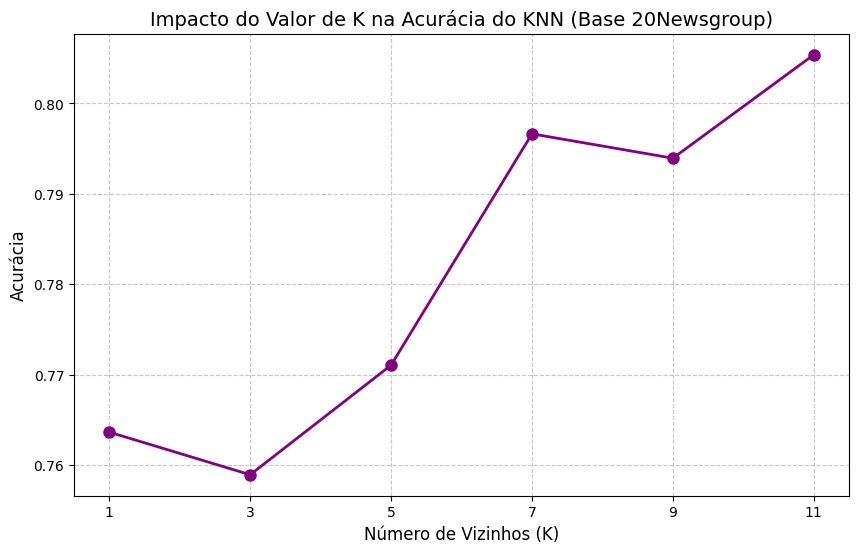

In [6]:
# Representação gráfica dos valores de K usados no KNN
exibir_grafico_comparativo(valores_k, resultados_acuracia, "20Newsgroup")
